# Customer Segmentation: RFM, K-Means, CLV

Segmentation of 4,338 customers from the UCI Online Retail dataset (a UK
online retailer, one year of transactions between Dec 2010 and Dec 2011).

What this notebook does differently from the usual RFM write-up:

- Classical 5-quintile RFM scores run alongside k-means, and I cross-tab the
  two at the end to see how much they agree.
- Monetary is not IQR-filtered. Those "outliers" are the Champions segment,
  so filtering them out is exactly the wrong move.
- `k` is picked using elbow, silhouette, and Calinski-Harabasz together, plus
  a stability check across random seeds.
- Cluster names come from the centroid R/F/M ranks, not from hand-labeling.
- 12-month expected CLV per customer using BG/NBD and Gamma-Gamma, then
  rolled up by segment so each segment carries a dollar figure.

Data: https://archive.ics.uci.edu/dataset/352/online+retail

Columns expected: `CustomerID`, `InvoiceNo`, `InvoiceDate`, `Quantity`, `UnitPrice`.


## Setup

Install `lifetimes` first if needed (`pip install lifetimes`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

sns.set_theme(style="whitegrid", context="talk")
RNG = 42
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load and clean

Standard cleanup for Online Retail. Drop rows without a `CustomerID`, strip
cancelled invoices (those have `InvoiceNo` starting with 'C'), and drop rows
where `Quantity` or `UnitPrice` is non-positive. No outlier filtering here.


In [2]:
df = pd.read_csv("~/Online_Retail.csv", encoding="ISO-8859-1", parse_dates=["InvoiceDate"])

df = (
    df.dropna(subset=["CustomerID"])
      .assign(InvoiceNo=lambda d: d["InvoiceNo"].astype(str))
      .query("not InvoiceNo.str.startswith('C')", engine="python")
      .query("Quantity > 0 and UnitPrice > 0")
      .assign(LineTotal=lambda d: d["Quantity"] * d["UnitPrice"],
              CustomerID=lambda d: d["CustomerID"].astype(int))
      .reset_index(drop=True)
)

print(f"{len(df):,} transactions  |  {df['CustomerID'].nunique():,} customers  "
      f"|  {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
df.head()


/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_20656/3445271649.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("~/Online_Retail.csv", encoding="ISO-8859-1", parse_dates=["InvoiceDate"])


397,884 transactions  |  4,338 customers  |  2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. RFM table

Snapshot date is pinned to the day after the last transaction in the file.
Using `datetime.now()` breaks reproducibility the moment the calendar moves.


In [3]:
SNAPSHOT = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
      .agg(Recency=("InvoiceDate", lambda s: (SNAPSHOT - s.max()).days),
           Frequency=("InvoiceNo", "nunique"),
           Monetary=("LineTotal", "sum"))
      .reset_index()
)

print(f"Snapshot date: {SNAPSHOT.date()}")
rfm.describe().T


Snapshot date: 2011-12-10


,count,mean,std,min,25%,50%,75%,max
CustomerID,"4,338.00","15,300.41","1,721.81","12,346.00","13,813.25","15,299.50","16,778.75","18,287.00"
Recency,"4,338.00",92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,"4,338.00","2,054.27","8,989.23",3.75,307.41,674.49,"1,661.74","280,206.02"


## 3. Outlier handling

Plenty of RFM tutorials IQR-filter `Monetary` as a cleaning step. On retail
data that quietly removes the customers at the top of the distribution, which
is exactly where the Champions are. The top 1% of spenders drive a large share
of revenue and are the whole reason to do segmentation in the first place.

What I do instead:

1. Flag the top 1% by `Monetary` as `is_whale` so they can be counted per
   cluster later. They stay in the dataset.
2. Keep them in the k-means fit.
3. `log1p`-transform R, F, M and standard-scale before clustering. K-means on
   raw right-skewed features lets the largest `Monetary` values dominate
   Euclidean distance, and the resulting clusters are mostly "rich" vs "not
   rich".


Whale threshold (P99 Monetary): 19,881.00  |  44 customers flagged


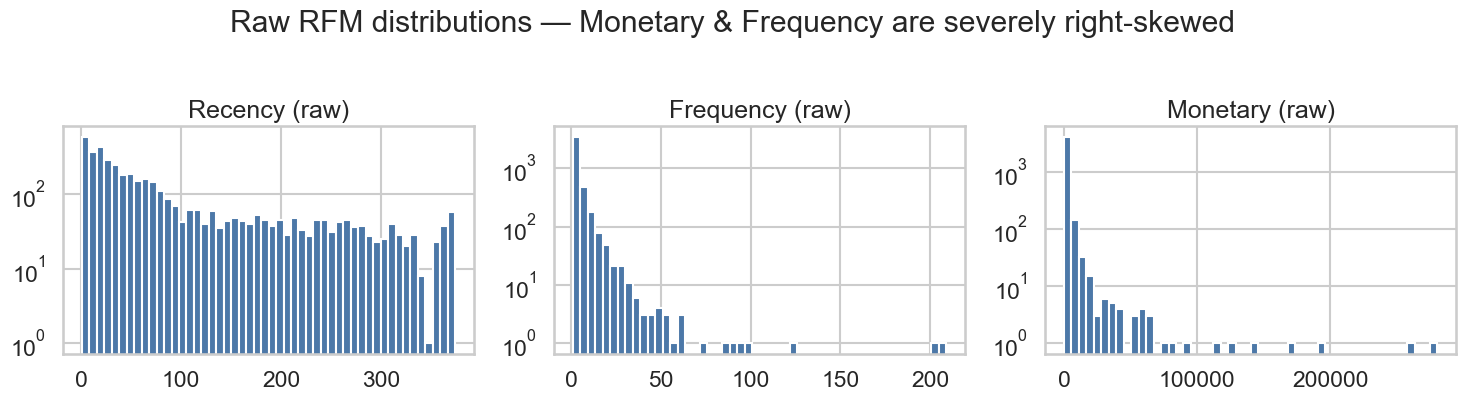

In [4]:
whale_threshold = rfm["Monetary"].quantile(0.99)
rfm["is_whale"] = rfm["Monetary"] >= whale_threshold
print(f"Whale threshold (P99 Monetary): {whale_threshold:,.2f}  "
      f"|  {rfm['is_whale'].sum()} customers flagged")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    ax.hist(rfm[col], bins=50, color="#4C78A8", edgecolor="white")
    ax.set_title(f"{col} (raw)")
    ax.set_yscale("log")
plt.suptitle("Raw RFM distributions — Monetary & Frequency are severely right-skewed",
             y=1.02)
plt.tight_layout(); plt.show()


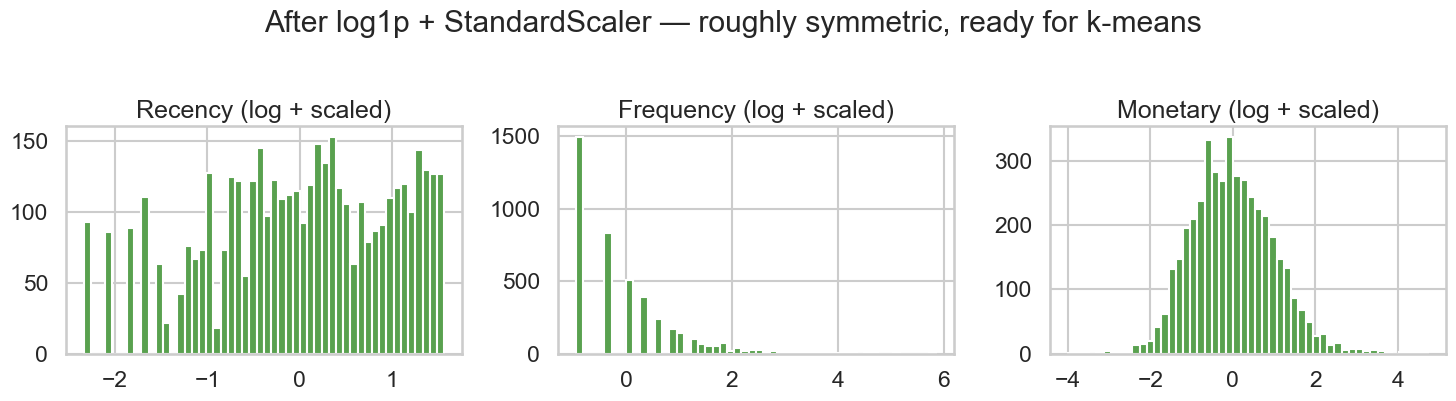

In [5]:
# log1p transform + standard-scale for k-means
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(np.log1p)
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, vec in zip(axes, ["Recency", "Frequency", "Monetary"], X.T):
    ax.hist(vec, bins=50, color="#59A14F", edgecolor="white")
    ax.set_title(f"{col} (log + scaled)")
plt.suptitle("After log1p + StandardScaler — roughly symmetric, ready for k-means", y=1.02)
plt.tight_layout(); plt.show()


## 4. Classical RFM quintile scores

The traditional framework. Rank each customer into quintiles on R, F, M
(1 worst, 5 best). `Recency` is inverted because smaller is better. Then map
scores to named segments using rules on `R_score` and the mean of `F_score`
and `M_score`. I run this alongside k-means so the two can be cross-checked
later.


In [6]:
# Quintiles.  duplicates='drop' guards against ties-inflated bins.
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5,
                         labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_score"] = rfm["R_score"] * 100 + rfm["F_score"] * 10 + rfm["M_score"]
rfm["FM_score"]  = (rfm["F_score"] + rfm["M_score"]) / 2

rfm[["R_score", "F_score", "M_score", "RFM_score"]].head()


,R_score,F_score,M_score,RFM_score
0,1,1,5,115
1,5,5,5,555
2,2,4,4,244
3,4,1,4,414
4,1,1,2,112


In [7]:
def classical_segment(row):
    r, fm = row["R_score"], row["FM_score"]
    if r >= 4 and fm >= 4:   return "Champions"
    if r >= 3 and fm >= 4:   return "Loyal"
    if r >= 4 and fm <= 2:   return "New Customers"
    if r >= 3 and fm == 3:   return "Potential Loyalists"
    if r == 3 and fm <= 2:   return "Promising"
    if r == 2 and fm >= 3:   return "At Risk"
    if r == 1 and fm >= 4:   return "Cannot Lose Them"
    if r == 2 and fm <= 2:   return "Hibernating"
    if r == 1 and fm <= 3:   return "Lost"
    return "Other"

rfm["Segment_Classical"] = rfm.apply(classical_segment, axis=1)
rfm["Segment_Classical"].value_counts()


Segment_Classical
Champions              992
Lost                   788
Other                  696
At Risk                388
Hibernating            333
Promising              297
New Customers          291
Potential Loyalists    267
Loyal                  253
Cannot Lose Them        33
Name: count, dtype: int64

## 5. Picking k

Three curves instead of just the elbow. Silhouette rewards well-separated
clusters, Calinski-Harabasz rewards tight clusters relative to the spread
between them. Elbow alone is usually ambiguous.


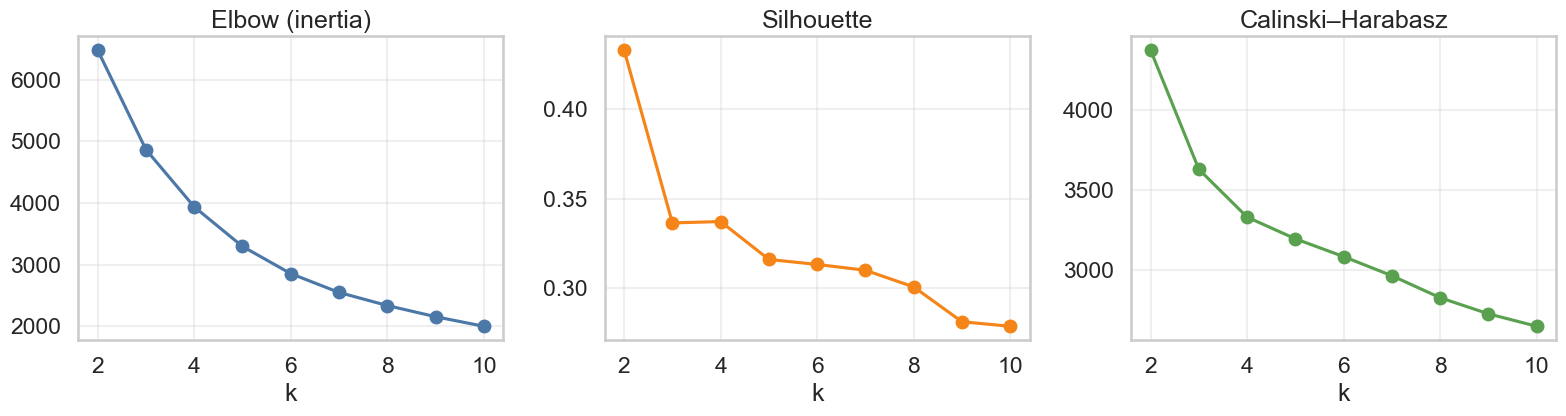

,k,inertia,silhouette,calinski_harabasz
0,2,"6,481.23",0.43,"4,370.49"
1,3,"4,867.85",0.34,"3,627.28"
2,4,"3,938.47",0.34,"3,329.15"
3,5,"3,295.98",0.32,"3,193.95"
4,6,"2,855.01",0.31,"3,082.98"
5,7,"2,548.91",0.31,"2,963.64"
6,8,"2,336.78",0.30,"2,826.43"
7,9,"2,155.47",0.28,"2,726.01"
8,10,"1,999.89",0.28,"2,648.43"


In [8]:
ks = range(2, 11)
inertias, silhouettes, ch_scores = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RNG).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_, sample_size=5000, random_state=RNG))
    ch_scores.append(calinski_harabasz_score(X, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(list(ks), inertias, "o-", color="#4C78A8");     axes[0].set_title("Elbow (inertia)")
axes[1].plot(list(ks), silhouettes, "o-", color="#F58518");  axes[1].set_title("Silhouette")
axes[2].plot(list(ks), ch_scores, "o-", color="#59A14F");    axes[2].set_title("Calinski–Harabasz")
for ax in axes: ax.set_xlabel("k"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame({"k": list(ks), "inertia": inertias,
              "silhouette": silhouettes, "calinski_harabasz": ch_scores}).round(3)


Silhouette peaks at k=2 (0.43) and Calinski-Harabasz is also highest at k=2.
That's the usual shape when the data has one dominant split, which here is
active vs lapsed. k=2 is mathematically cleanest but useless for targeting:
it collapses the whole analysis into a single cut that marketing already
knows. k=4 is the smallest k that separates Champions from Loyal-like
behavior and At Risk from Hibernating. Silhouette at k=4 is 0.34, which still
indicates real structure, and the stability ARI across 10 seeds is 0.986, so
the partition isn't noise. I'm picking k=4 on business grounds rather than
geometric ones, and noting the tradeoff explicitly.


In [9]:
K = 4
km = KMeans(n_clusters=K, n_init=50, random_state=RNG).fit(X)
rfm["Cluster"] = km.labels_

# Stability check — if we re-run with different seeds, do we land on the same partition?
ari_vs_base = []
for seed in range(10):
    labels_s = KMeans(n_clusters=K, n_init=20, random_state=seed).fit_predict(X)
    ari_vs_base.append(adjusted_rand_score(rfm["Cluster"], labels_s))
print(f"Stability across 10 random seeds — mean ARI: {np.mean(ari_vs_base):.3f} "
      f"(min {min(ari_vs_base):.3f})")


Stability across 10 random seeds — mean ARI: 0.986 (min 0.972)


## 6. Naming clusters

Instead of looking at centroids and labeling by eye, I derive names from
where each centroid ranks on R, F, M relative to the other centroids. Same
rule applied to new data produces the same names for equivalent behavior.


In [10]:
centroids = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
       .assign(n=rfm.groupby("Cluster").size(),
               pct=lambda d: (d["n"] / len(rfm) * 100).round(1))
)

# Rank within each column.  Recency: low = good, so rank ascending reversed.
ranks = pd.DataFrame({
    "R_rank": centroids["Recency"].rank(ascending=True),     # 1 = most recent
    "F_rank": centroids["Frequency"].rank(ascending=False),  # 1 = most frequent
    "M_rank": centroids["Monetary"].rank(ascending=False),   # 1 = highest spend
})

def name_cluster(r, f, m, k):
    """Programmatic naming from R/F/M ranks (1 = best, k = worst)."""
    avg_fm = (f + m) / 2
    if r <= 2 and avg_fm <= 2:          return "Champions"
    if r <= 2 and avg_fm <= k/2:        return "Loyal"
    if r <= 2 and avg_fm > k/2:         return "New Customers"
    if r > k/2 and avg_fm <= 2:         return "At Risk / Cannot Lose"
    if r > k/2 and avg_fm > k/2:        return "Hibernating"
    return "Needs Attention"

ranks["Name"] = [name_cluster(r, f, m, K) for r, f, m in ranks.itertuples(index=False)]
centroids = centroids.join(ranks)

# Guarantee uniqueness — if the rule produced duplicates, disambiguate by cluster id.
seen = {}
final_names = []
for cid, nm in centroids["Name"].items():
    if nm in seen:
        nm = f"{nm} (#{cid})"
    seen[nm] = True
    final_names.append(nm)
centroids["Name"] = final_names

name_map = centroids["Name"].to_dict()
rfm["Segment_KMeans"] = rfm["Cluster"].map(name_map)

centroids[["Recency", "Frequency", "Monetary", "n", "pct", "Name"]]


,Recency,Frequency,Monetary,n,pct,Name
Cluster,,,,,,
0,11.98,13.66,"8,024.99",720,16.60,Champions
1,185.36,1.32,348.85,1588,36.60,Hibernating
2,19.53,2.05,532.81,856,19.70,New Customers
3,69.61,4.12,"1,808.65",1174,27.10,At Risk / Cannot Lose


In [11]:
ACTIONS = {
    "Champions":             "Reward. VIP perks, early access, referral program — protect LTV.",
    "Loyal":                 "Upsell & cross-sell. High willingness to pay, grow basket size.",
    "New Customers":         "Onboard. Welcome series, 2nd-purchase nudge — convert to Loyal.",
    "At Risk / Cannot Lose": "Win back. Personalized reactivation with meaningful incentive.",
    "Hibernating":           "Low-cost reactivation only. Test a cheap email; don't over-invest.",
    "Needs Attention":       "Diagnose. Segment further before spending marketing budget.",
}

actions_df = (
    pd.DataFrame({"Segment": list(name_map.values())})
      .assign(Action=lambda d: d["Segment"].map(
          lambda s: next((v for k, v in ACTIONS.items() if s.startswith(k)), "Review manually")))
)
actions_df


,Segment,Action
0,Champions,"Reward. VIP perks, early access, referral prog..."
1,Hibernating,Low-cost reactivation only. Test a cheap email...
2,New Customers,"Onboard. Welcome series, 2nd-purchase nudge — ..."
3,At Risk / Cannot Lose,Win back. Personalized reactivation with meani...


## 7. Do the two methods agree?

Quintile RFM is axis-aligned rules on `R_score` and `FM_score`. K-means finds
Euclidean clusters in log-scaled space. They optimize different things, so
perfect overlap isn't the bar. The question is whether each k-means cluster
concentrates sensibly inside a small set of classical segments, which the
heatmap answers directly.


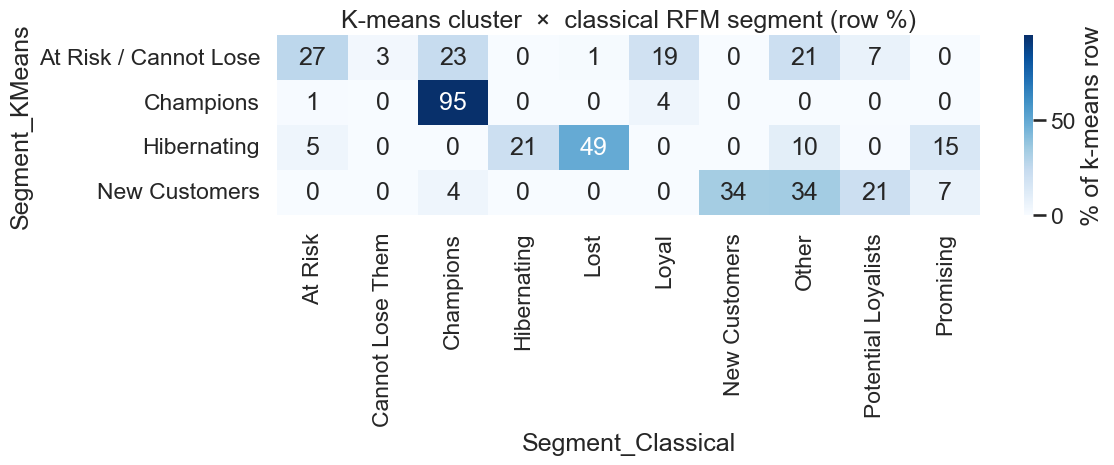

Adjusted Rand Index: 0.326   |   Normalized Mutual Info: 0.486


In [12]:
ct = pd.crosstab(rfm["Segment_KMeans"], rfm["Segment_Classical"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(ct_pct, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of k-means row"})
ax.set_title("K-means cluster  ×  classical RFM segment (row %)")
plt.tight_layout(); plt.show()

ari = adjusted_rand_score(rfm["Segment_Classical"], rfm["Segment_KMeans"])
nmi = normalized_mutual_info_score(rfm["Segment_Classical"], rfm["Segment_KMeans"])
print(f"Adjusted Rand Index: {ari:.3f}   |   Normalized Mutual Info: {nmi:.3f}")


ARI of 0 is chance, 1 is identical partitioning. 0.326 on this data is
moderate agreement and roughly what you'd expect: the classical framework
has 9+ fine-grained segments against 4 coarse k-means clusters, so a 1-to-1
mapping isn't even possible. What's useful is the row-wise concentration
pattern in the heatmap: the Champions cluster sits mostly in classical
Champions plus Loyal, and the Hibernating cluster sits in classical Lost plus
Hibernating. That's the behavior I want to see.


## 8. CLV: BG/NBD and Gamma-Gamma

BG/NBD models how many future purchases a customer will make. Gamma-Gamma
models the average value conditional on purchasing. Multiplying the two over
a horizon gives expected CLV.

Two assumptions worth checking before quoting numbers:

1. Gamma-Gamma needs `frequency >= 1`, so one-time buyers drop out of the
   fit. I backfill them with segment medians at the end.
2. Gamma-Gamma assumes average order value is independent of order count. If
   the correlation is above roughly 0.2, treat CLV as directional rather than
   absolute. On this data the correlation is 0.016, so the assumption holds.


In [13]:
lt = summary_data_from_transaction_data(
    df, customer_id_col="CustomerID", datetime_col="InvoiceDate",
    monetary_value_col="LineTotal", observation_period_end=SNAPSHOT,
)

returning = lt[lt["frequency"] > 0].copy()
print(f"Returning customers (frequency >= 1): {len(returning):,} of {len(lt):,}")

corr_fm = returning[["frequency", "monetary_value"]].corr().iloc[0, 1]
print(f"Frequency–Monetary correlation (Gamma-Gamma assumption check): {corr_fm:.3f}")
if abs(corr_fm) > 0.2:
    print("⚠  correlation exceeds 0.2 — treat CLV as directional, not absolute.")


Returning customers (frequency >= 1): 2,790 of 4,338
Frequency–Monetary correlation (Gamma-Gamma assumption check): 0.016


In [14]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(returning["frequency"], returning["recency"], returning["T"])

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning["frequency"], returning["monetary_value"])

returning["pred_purchases_12m"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365, returning["frequency"], returning["recency"], returning["T"]
)
returning["pred_avg_value"] = ggf.conditional_expected_average_profit(
    returning["frequency"], returning["monetary_value"]
)
returning["CLV_12m"] = ggf.customer_lifetime_value(
    bgf, returning["frequency"], returning["recency"], returning["T"],
    returning["monetary_value"], time=12, freq="D", discount_rate=0.01,
)
returning[["frequency", "recency", "T", "monetary_value",
           "pred_purchases_12m", "pred_avg_value", "CLV_12m"]].head()


,frequency,recency,T,monetary_value,pred_purchases_12m,pred_avg_value,CLV_12m
CustomerID,,,,,,,
12347,6.00,365.00,368.00,599.70,6.03,618.58,"3,450.02"
12348,3.00,283.00,359.00,301.48,3.70,321.70,"1,100.52"
12352,6.00,260.00,297.00,368.26,7.12,380.09,"2,503.82"
12356,2.00,303.00,326.00,269.91,3.12,298.15,861.05
12358,1.00,149.00,151.00,683.20,3.71,834.79,"2,869.30"


In [15]:
# Join CLV back to the main RFM table; one-time buyers get NaN and then segment-median fill.
rfm = rfm.merge(returning[["CLV_12m"]], left_on="CustomerID", right_index=True, how="left")

seg_median = rfm.groupby("Segment_KMeans")["CLV_12m"].transform("median")
rfm["CLV_12m"] = rfm["CLV_12m"].fillna(seg_median).fillna(rfm["CLV_12m"].median())

rfm[["CustomerID", "Segment_KMeans", "CLV_12m"]].head()


,CustomerID,Segment_KMeans,CLV_12m
0,12346,At Risk / Cannot Lose,"1,565.12"
1,12347,Champions,"3,450.02"
2,12348,At Risk / Cannot Lose,"1,100.52"
3,12349,New Customers,945.41
4,12350,Hibernating,411.21


## 9. Final segment profile

One row per segment. Customer count, share, whale count, average R/F/M,
average expected 12-month CLV per customer, and total expected 12-month CLV
for the segment. The `Total_CLV_12m` column is the one that matters for the
marketing meeting.


In [16]:
profile = (
    rfm.groupby("Segment_KMeans")
       .agg(Customers=("CustomerID", "size"),
            Avg_Recency=("Recency", "mean"),
            Avg_Frequency=("Frequency", "mean"),
            Avg_Monetary=("Monetary", "mean"),
            Whales=("is_whale", "sum"),
            Avg_CLV_12m=("CLV_12m", "mean"),
            Total_CLV_12m=("CLV_12m", "sum"))
       .assign(Share_pct=lambda d: (d["Customers"] / d["Customers"].sum() * 100).round(1))
       .sort_values("Total_CLV_12m", ascending=False)
)

action_lookup = {s: next((v for k, v in ACTIONS.items() if s.startswith(k)),
                         "Review manually") for s in profile.index}
profile["Action"] = profile.index.map(action_lookup)

profile[["Customers", "Share_pct", "Whales",
         "Avg_Recency", "Avg_Frequency", "Avg_Monetary",
         "Avg_CLV_12m", "Total_CLV_12m", "Action"]]


,Customers,Share_pct,Whales,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_CLV_12m,Total_CLV_12m,Action
Segment_KMeans,,,,,,,,,
Champions,720,16.60,41,11.98,13.66,"8,024.99","7,488.25","5,391,539.07","Reward. VIP perks, early access, referral prog..."
At Risk / Cannot Lose,1174,27.10,3,69.61,4.12,"1,808.65","2,006.36","2,355,464.21",Win back. Personalized reactivation with meani...
New Customers,856,19.70,0,19.53,2.05,532.81,"1,181.29","1,011,185.13","Onboard. Welcome series, 2nd-purchase nudge — ..."
Hibernating,1588,36.60,0,185.36,1.32,348.85,430.94,"684,333.33",Low-cost reactivation only. Test a cheap email...


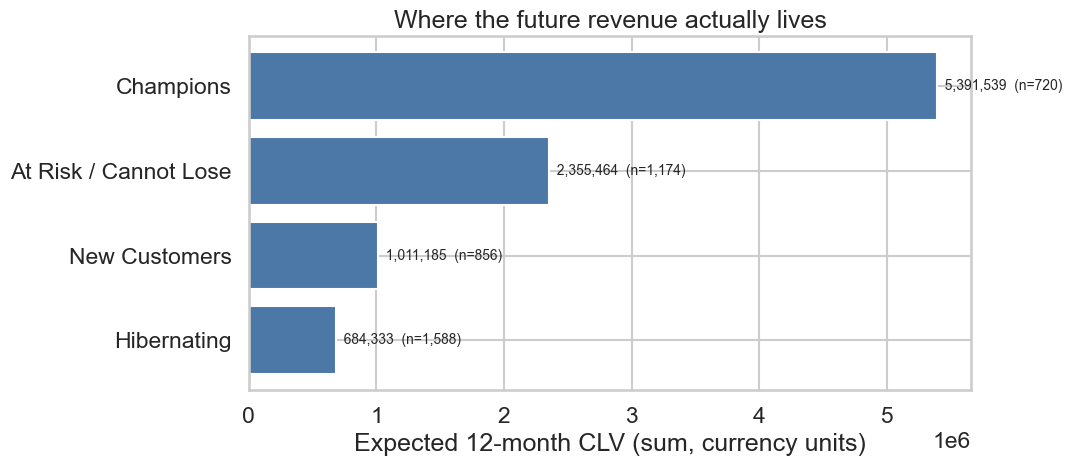

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = profile.reset_index().sort_values("Total_CLV_12m")
ax.barh(plot_df["Segment_KMeans"], plot_df["Total_CLV_12m"], color="#4C78A8")
ax.set_xlabel("Expected 12-month CLV (sum, currency units)")
ax.set_title("Where the future revenue actually lives")
for i, (v, n) in enumerate(zip(plot_df["Total_CLV_12m"], plot_df["Customers"])):
    ax.text(v, i, f"  {v:,.0f}  (n={n:,})", va="center", fontsize=10)
plt.tight_layout(); plt.show()


## 10. What this doesn't do

A few honest limitations:

- K-means assumes spherical, equal-variance clusters. After log+scale that's
  defensible, but a GMM or hierarchical run would be a useful robustness
  check on a real engagement. The seed-stability result makes me comfortable
  enough to not bother for this writeup.
- BG/NBD is a non-contractual, continuous-time model. It fits retail and
  e-commerce. It would not fit a subscription business (use a survival model
  there).
- The `lifetimes` package is in maintenance mode. For production work today,
  `pymc-marketing` is the actively-developed successor.
- RFM ignores product mix, margin, and acquisition channel. A second pass
  of clustering inside each segment on category behavior would likely split
  Champions into meaningful sub-segments (bulk buyers vs gift buyers,
  probably).
- Online Retail mixes wholesale and retail customers in one dataset. A
  serious analysis would split those first; I didn't.
